# 02 — Amostras (`samples`) e separabilidade (`separability`)

Origem: script 11. Convenção: `df_samples` é um `DataFrame` com a coluna `Class` e as demais colunas numéricas, e nenhuma função depende da posição da coluna `Class`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sar_classification import (distributions as dist, samples as smp, models as mdl,
                                raster_io as rio, separability as sep, validation as val,
                                fitting as fit, plots, diagnostics as diag)

In [2]:
# Dados fictícios gerados pelo próprio catálogo (substitua pelos seus df_samples)
rng = np.random.default_rng(42)
classes = ['F', 'VS', 'PA', 'SE']

def simulate(distribution, params_by_class, n, columns, ENL=None):
    parts = [pd.DataFrame(dist.get_distribution(distribution)['sample'](n, p, ENL, rng), columns=columns).assign(Class=c)
             for c, p in params_by_class.items()]
    return pd.concat(parts, ignore_index=True)[['Class'] + columns]

def random_cov(scale):
    A = rng.normal(0, scale, (3, 3))
    return A @ A.T + 1e-4 * np.eye(3)

df_gauss = simulate('gaussian', {c: {'mean': np.array(m), 'covariance_matrix': random_cov(0.02)} for c, m in
                    {'F': [0.20, 0.05, 0.30], 'VS': [0.22, 0.07, 0.28], 'PA': [0.10, 0.15, 0.20], 'SE': [0.05, 0.25, 0.10]}.items()},
                    120, ['B1', 'B2', 'B3'])
df_gamma = simulate('gamma', {c: {'alpha': 3.0, 'beta': 3.0 / mu} for c, mu in
                    {'F': 0.08, 'VS': 0.06, 'PA': 0.03, 'SE': 0.015}.items()}, 150, ['HH'], ENL=3)
df_pair = simulate('intensity_joint_distribution', {c: {'mu1': a, 'mu2': b, 'ro2': r} for c, (a, b, r) in
                   {'F': (0.08, 0.020, 0.25), 'VS': (0.06, 0.012, 0.16), 'PA': (0.03, 0.006, 0.09), 'SE': (0.015, 0.004, 0.49)}.items()},
                   150, ['HH', 'HV'], ENL=4)
print(df_gauss.shape, df_gamma.shape, df_pair.shape)

(480, 4) (600, 2) (600, 3)


## 1. Conjunto amostral

| Função | Descrição |
|---|---|
| `build_samples_table(attribute_list, classes)` | junta uma tabela de atributos por classe |
| `split_by_class(df, classes)` | `{classe: array}` |
| `downsample_samples(df, ratio=1, random_state=None)` | limita cada classe a ⌊ratio × menor classe⌋ |
| `generalize_classes(df, hierarchical_levels, level=1)` | funde classes em `'C1+C2'` (nível **1-based**, como no R) |
| `split_samples(df, ratio=None, samples_per_class=None, random_state=None)` | `(treino, validação)` estratificado |

**Regra de `split_samples`** (conferida no código-fonte do `caret::createDataPartition`): treino = ⌈n × ratio⌉ por classe; classe com 1 amostra vai inteira para o treino. Com `samples_per_class`, classes com n ≤ `samples_per_class` ficam sem validação.

In [3]:
train, valid = smp.split_samples(df_gauss, ratio=0.7, random_state=1)
print('Treino   :', train.groupby('Class').size().to_dict())
print('Validação:', valid.groupby('Class').size().to_dict())

Treino   : {'F': 84, 'PA': 84, 'SE': 84, 'VS': 84}
Validação: {'F': 36, 'PA': 36, 'SE': 36, 'VS': 36}


## 2. Separabilidade

As distâncias são calculadas com os parâmetros ajustados por `models.fit_model` e com a forma fechada registrada no catálogo.

| Função | Retorno |
|---|---|
| `bhattacharyya_matrix(df, classes, distribution='gaussian', ENL=None)` | `DataFrame` simétrico |
| `jeffries_matusita_matrix(df, classes, distribution, ENL)` | $JM = \sqrt{2(1-e^{-B})}$, em $[0,\sqrt{2}]$ |
| `mean_jm_distance(df, classes, distribution, ENL)` | média dos pares |
| `forward_selection_jm(df, classes, all_features, distribution, ENL)` | `(distances, results)` |

`forward_selection_jm` reproduz `exhaustive_search_jm_optimal`: busca exaustiva no 1º nível e, depois, combinações que contêm o melhor conjunto anterior. O conjunto-base só muda quando a média JM aumenta.

In [4]:
print('Bhattacharyya (gaussiana):'); print(sep.bhattacharyya_matrix(df_gauss, classes).round(3))
print('\nJeffries-Matusita:'); print(sep.jeffries_matusita_matrix(df_gauss, classes).round(3))
print('\nBhattacharyya (Gama, ENL = 3):'); print(sep.bhattacharyya_matrix(df_gamma, classes, 'gamma', 3).round(3))

Bhattacharyya (gaussiana):
         F      VS      PA      SE
F    0.000   0.692  10.793  11.121
VS   0.692   0.000   5.819  11.300
PA  10.793   5.819   0.000   2.711
SE  11.121  11.300   2.711   0.000

Jeffries-Matusita:
        F     VS     PA     SE
F   0.000  1.000  1.414  1.414
VS  1.000  0.000  1.412  1.414
PA  1.414  1.412  0.000  1.366
SE  1.414  1.414  1.366  0.000

Bhattacharyya (Gama, ENL = 3):
        F     VS     PA     SE
F   0.000  0.039  0.262  0.873
VS  0.039  0.000  0.102  0.574
PA  0.262  0.102  0.000  0.208
SE  0.873  0.574  0.208  0.000


In [5]:
distances, results = sep.forward_selection_jm(df_gauss, classes, ['B1', 'B2', 'B3'])
results

,Features,Gain,JM_dist
0,B3,0.000000,1.234557
1,"B3, B1",0.058802,1.307152
2,"B3, B1, B2",0.022677,1.336795


## 3. Agrupamento hierárquico

| Função | Descrição |
|---|---|
| `hierarchical_clustering(dist_matrix, method='ward')` | matriz de ligação; `'ward'` equivale a `hclust(method='ward.D2')` |
| `extract_hierarchy(Z, labels)` | `{'lvl_1': [...], ...}`: grupo formado em cada fusão |
| `plots.plot_dendrogram(Z, labels, title)` | dendrograma |
| `plots.boxplots_by_class(df, classes, title)` | boxplots (parte gráfica de `data_analysis`) |

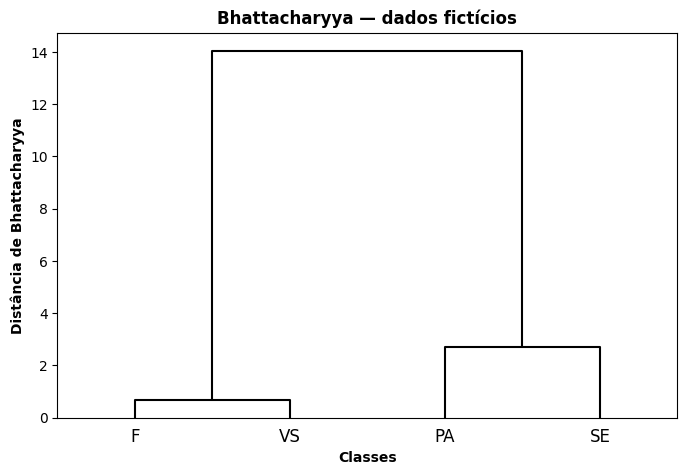

{'lvl_1': ['F', 'VS'], 'lvl_2': ['PA', 'SE'], 'lvl_3': ['F', 'VS', 'PA', 'SE']}

In [6]:
B = sep.bhattacharyya_matrix(df_gauss, classes)
Z = sep.hierarchical_clustering(B)
plots.plot_dendrogram(Z, classes, title='Bhattacharyya — dados fictícios')
levels = sep.extract_hierarchy(Z, classes)
levels

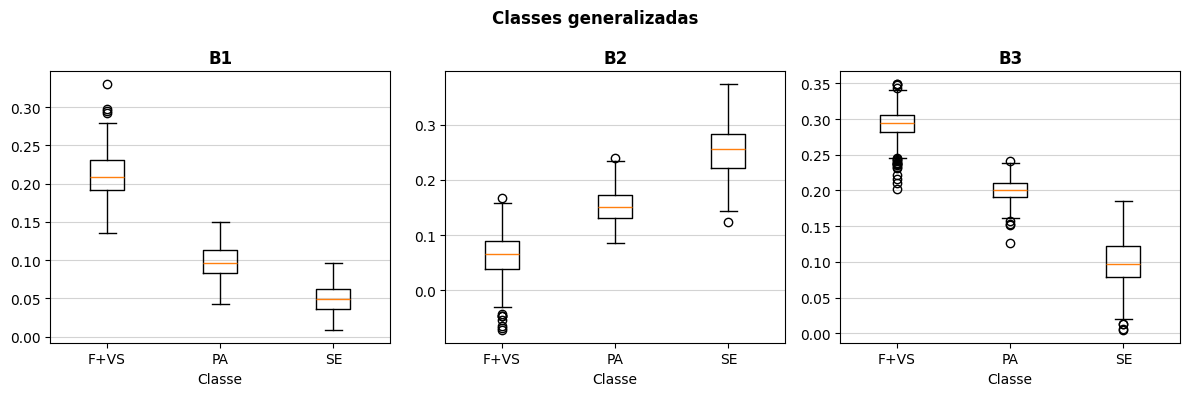

In [7]:
df_gen = smp.generalize_classes(df_gauss, [[levels['lvl_1']]], level=1)
plots.boxplots_by_class(df_gen, sorted(df_gen['Class'].unique()), title='Classes generalizadas')